In [ ]:
from pathlib import Path
import numpy as np
import sys
sys.path.append(str(Path("../src").resolve()))

from config import (
    RAW_ROOT,
    PROCESSED_GROUP1,
    NOTCH_FREQ,
    LOW_FREQ,
    HIGH_FREQ,
    TARGET_SFREQ,
    WINDOW_SIZE_SEC,
    STEP_SEC,
    BAD_CHANNEL_Z_THRESH
)

from utils import (
    load_raw_edf,
    prepare_raw,
    apply_filters,
    parse_chbmit_summary,
    detect_bad_channels,
    reorder_channels,
    zscore_normalize,
    create_windows_and_labels,
    save_processed_data,
    plot_grouped_channel_comparison,
    plot_raw_vs_normalized_signal,
    plot_suspicious_channels,
    check_model_input_ready,
    plot_seizure_vs_nonseizure_windows,
    plot_label_distribution,
    plot_psd_before_after
)


# File setup

patient_name = "chb01"
file_name = "chb01_01.edf"

patient_folder = RAW_ROOT / patient_name
summary_path = patient_folder / f"{patient_name}-summary.txt"
file_path = patient_folder / file_name

# create output folder if it does not exist
output_folder = PROCESSED_GROUP1 / patient_name
output_folder.mkdir(parents=True, exist_ok=True)


# 1. Reading seizure information from summary file

summary_dict = parse_chbmit_summary(summary_path)
seizure_intervals = summary_dict.get(file_name, [])

print(f"Processing patient: {patient_name}")
print(f"Processing file: {file_name}")
print(f"Seizure intervals: {seizure_intervals}")

# 2. Load raw EDF file

raw = load_raw_edf(file_path)
print("\nLoaded raw file successfully")
print(raw)


# 3. Keep EEG channels only and set them as EEG type

raw = prepare_raw(raw)

print("\nEEG channels kept:")
print(raw.ch_names)
print(f"Number of EEG channels: {len(raw.ch_names)}")


# 4. Save expected channels from this first clean file
# For Group 1 this file can be used as the reference channel order

expected_channels = raw.ch_names.copy()


# 5. Reorder channels to ensure consistency

raw = reorder_channels(raw, expected_channels)

# save channel names for later plotting
ch_names = raw.ch_names.copy()


# 6. Check sampling rate and resample only if needed

print(f"\nOriginal sampling rate: {raw.info['sfreq']} Hz")


# 7. Apply filtering
# notch filter removes powerline noise
# band-pass filter keeps useful EEG frequencies

raw_before_filter = raw.copy()   # keep for plotting later

raw = apply_filters(
    raw,
    notch_freq=NOTCH_FREQ,
    l_freq=LOW_FREQ,
    h_freq=HIGH_FREQ
)

raw_after_filter = raw.copy()    # keep for plotting later

print(f"\nFiltering done: notch {NOTCH_FREQ} Hz + band-pass {LOW_FREQ}-{HIGH_FREQ} Hz")


# 8. Detect suspicious bad channels
# We only mark them for checking, not remove them automatically

bad_channels, channel_std = detect_bad_channels(raw, z_thresh=BAD_CHANNEL_Z_THRESH)
raw.info["bads"] = bad_channels

print(f"\nSuspicious bad channels: {bad_channels}")


# 9. Convert EEG signal to NumPy array

data_before_norm = raw.get_data()   # keep filtered but not normalized data for plotting later
sfreq = raw.info["sfreq"]

print(f"\nData shape before normalization: {data_before_norm.shape}")
print(f"Sampling frequency used: {sfreq}")


# 10. Normalize the signal channel by channel
# This helps the ML model because all channels are put on a similar scale

data_after_norm = zscore_normalize(data_before_norm.copy())

# keep final normalized data 
data = data_after_norm

print("Normalization done")


# 11. Split signal into overlapping windows and label them
# Each window becomes one training example

X, y = create_windows_and_labels(
    data=data,
    sfreq=sfreq,
    window_size_sec=WINDOW_SIZE_SEC,
    step_sec=STEP_SEC,
    seizure_intervals=seizure_intervals
)

print(f"\nWindowed data shape: {X.shape}")
print(f"Labels shape: {y.shape}")
print(f"Number of seizure windows: {np.sum(y)}")
print(f"Number of non-seizure windows: {len(y) - np.sum(y)}")


# 12. Save processed result

'''
save_path = output_folder / f"{Path(file_name).stem}_processed.npz"
save_processed_data(save_path, X, y)

print("\nPreprocessing finished successfully for first Group 1 file")
'''

Processing patient: chb01
Processing file: chb01_01.edf
Seizure intervals: []


C:\Users\MSI\Desktop\EEG_FYP\src\utils.py:12: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)



Loaded raw file successfully
<RawEDF | chb01_01.edf, 23 x 921600 (3600.0 s), ~161.7 MiB, data loaded>

EEG channels kept:
['FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1', 'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'FP2-F8', 'F8-T8', 'T8-P8-0', 'P8-O2', 'FZ-CZ', 'CZ-PZ', 'P7-T7', 'T7-FT9', 'FT9-FT10', 'FT10-T8', 'T8-P8-1']
Number of EEG channels: 23

Original sampling rate: 256.0 Hz

Filtering done: notch 60 Hz + band-pass 0.5-40 Hz

Channel STD values:
FP1-F7: 0.000070
F7-T7: 0.000042
T7-P7: 0.000025
P7-O1: 0.000018
FP1-F3: 0.000069
F3-C3: 0.000026
C3-P3: 0.000019
P3-O1: 0.000022
FP2-F4: 0.000058
F4-C4: 0.000023
C4-P4: 0.000018
P4-O2: 0.000022
FP2-F8: 0.000058
F8-T8: 0.000037
T8-P8-0: 0.000026
P8-O2: 0.000026
FZ-CZ: 0.000022
CZ-PZ: 0.000021
P7-T7: 0.000025
T7-FT9: 0.000029
FT9-FT10: 0.000053
FT10-T8: 0.000028
T8-P8-1: 0.000026

Suspicious channels: ['FP1-F7', 'FP1-F3']

Suspicious bad channels: ['FP1-F7', 'FP1-F3']

Data shape before normalization: (23, 921600)
Sam

'\nsave_path = output_folder / f"{Path(file_name).stem}_processed.npz"\nsave_processed_data(save_path, X, y)\n\nprint("\nPreprocessing finished successfully for first Group 1 file")\n'

In [2]:
#cheks for the bibeline if its working 
#checks the windowing and labeling part if its working
print("X shape:", X.shape)
print("y shape:", y.shape)
#chesk labels 


print("Unique labels:", np.unique(y))
print("Seizure windows:", np.sum(y == 1))
print("Non-seizure windows:", np.sum(y == 0))

#compare before anf after filtering

#cheking normalization
print("Mean after normalization:", np.mean(data[0]))
print("STD after normalization:", np.std(data[0]))




X shape: (1439, 23, 1280)
y shape: (1439,)
Unique labels: [0]
Seizure windows: 0
Non-seizure windows: 1439
Mean after normalization: -5.520275594663973e-18
STD after normalization: 0.9998568854082412


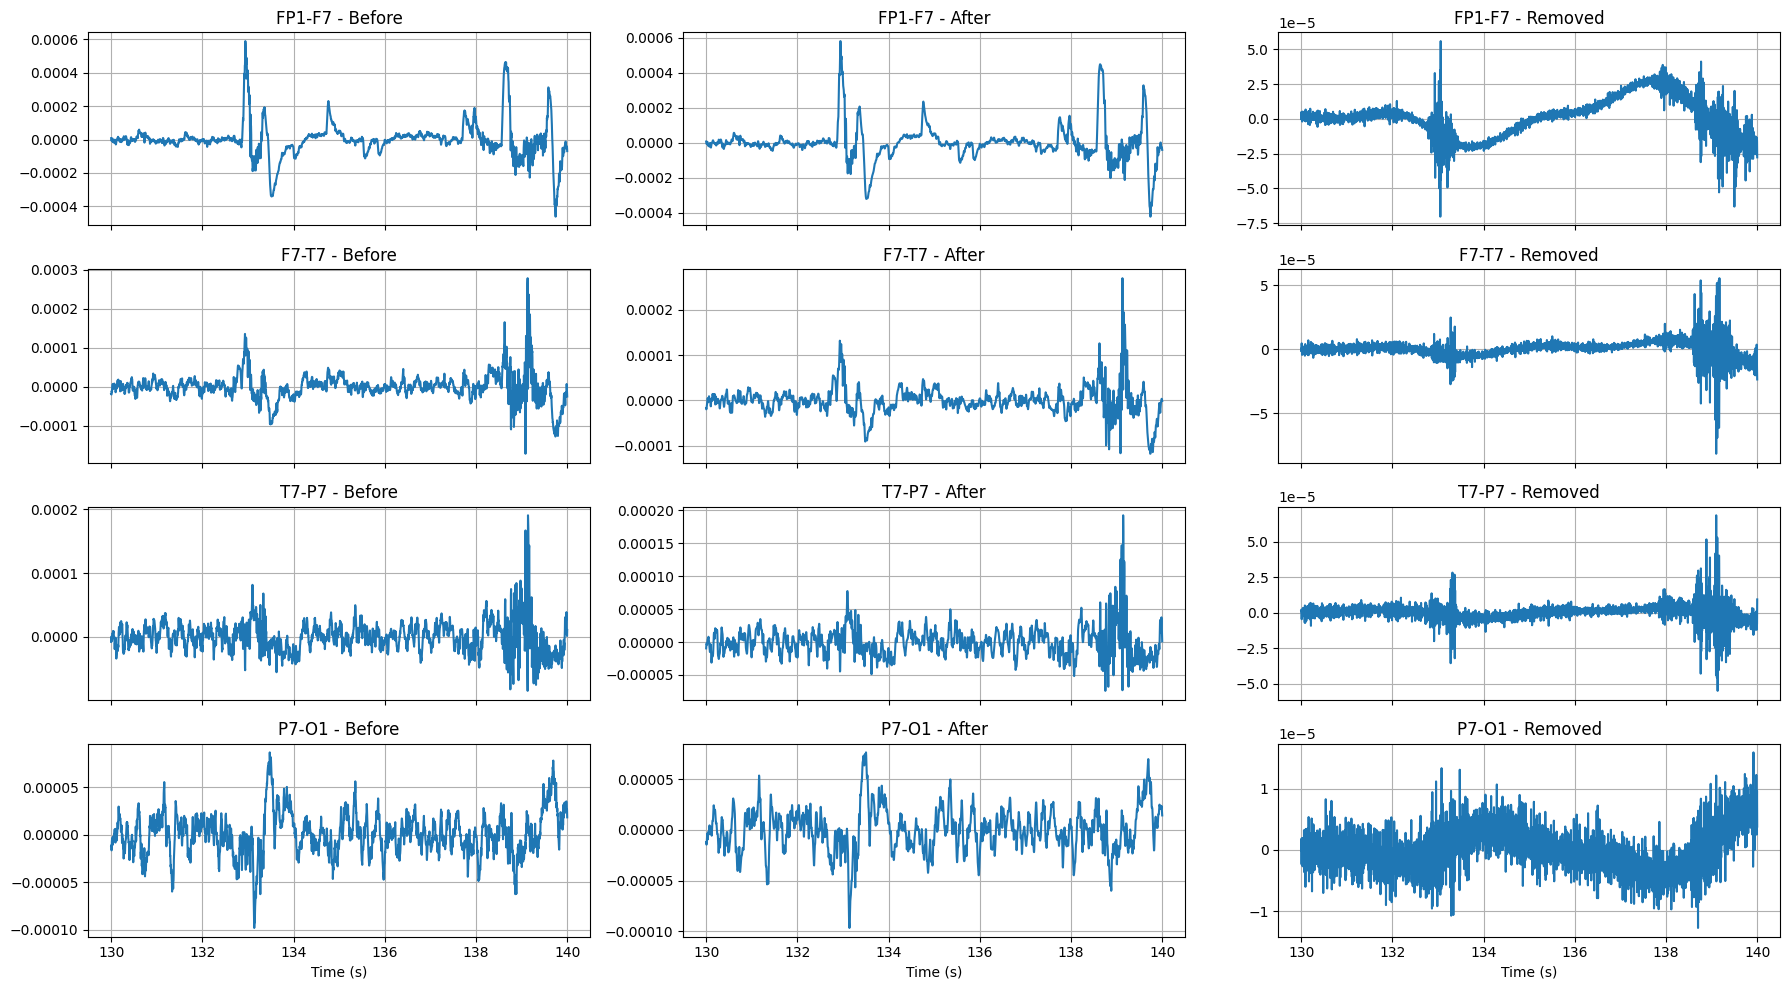

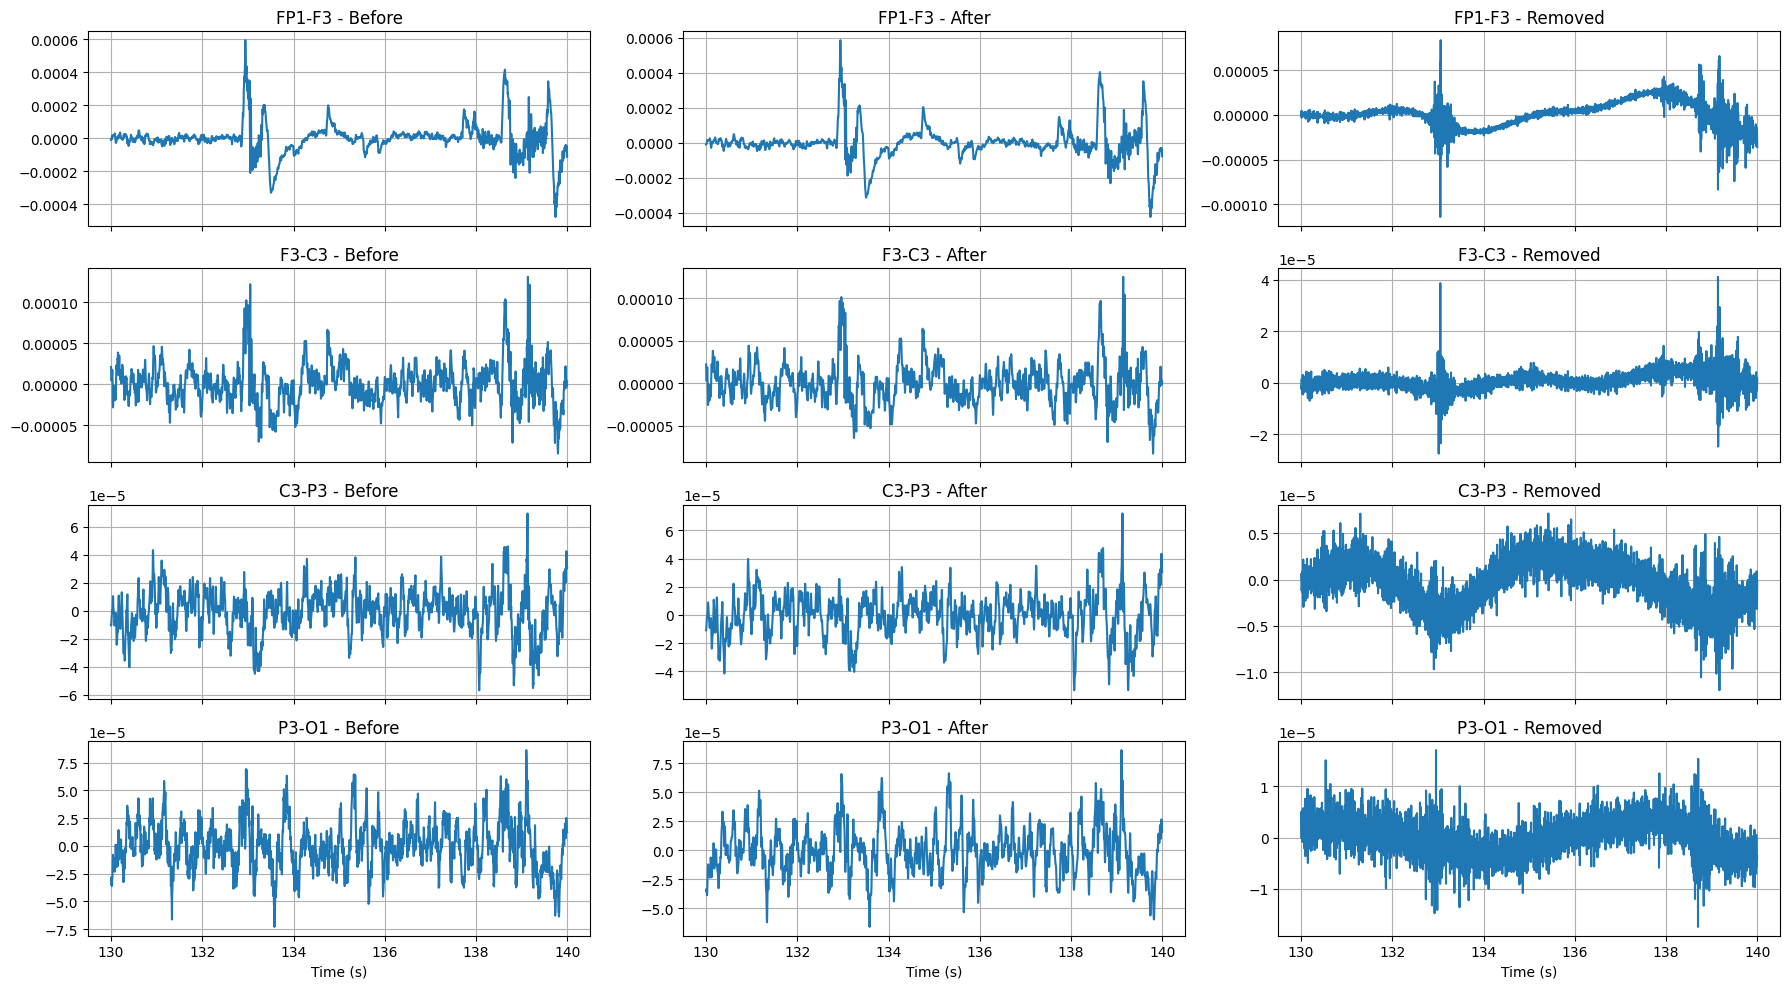

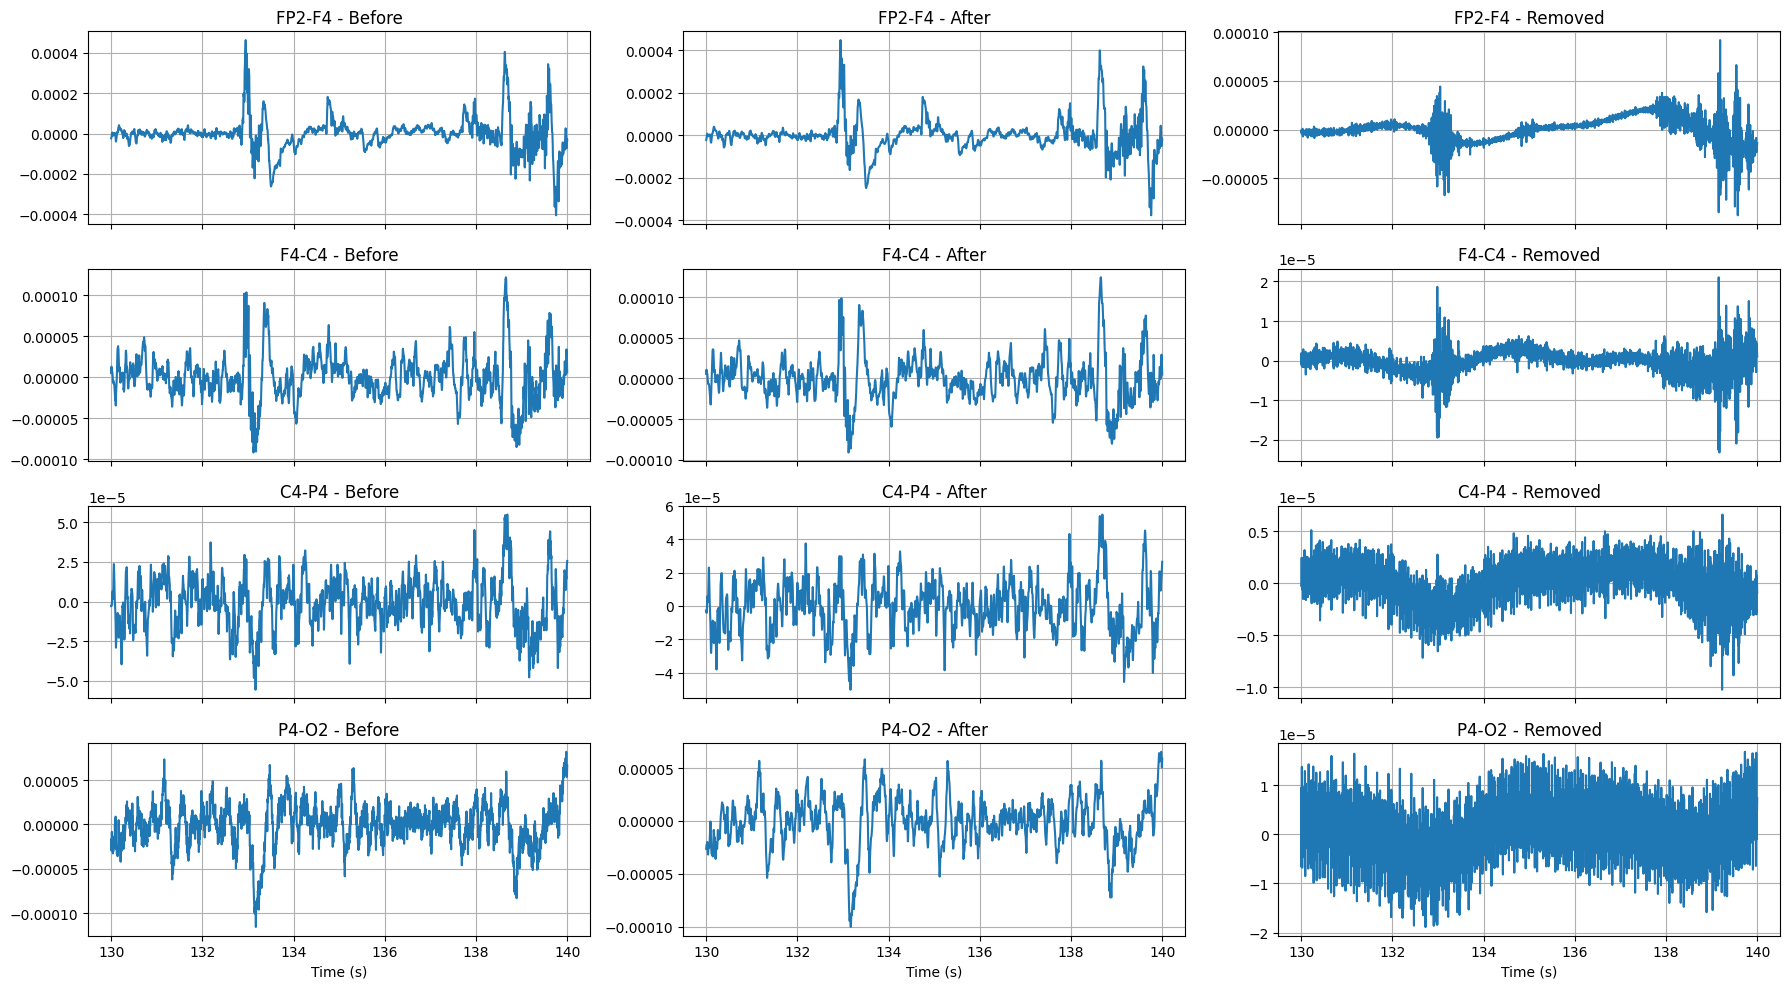

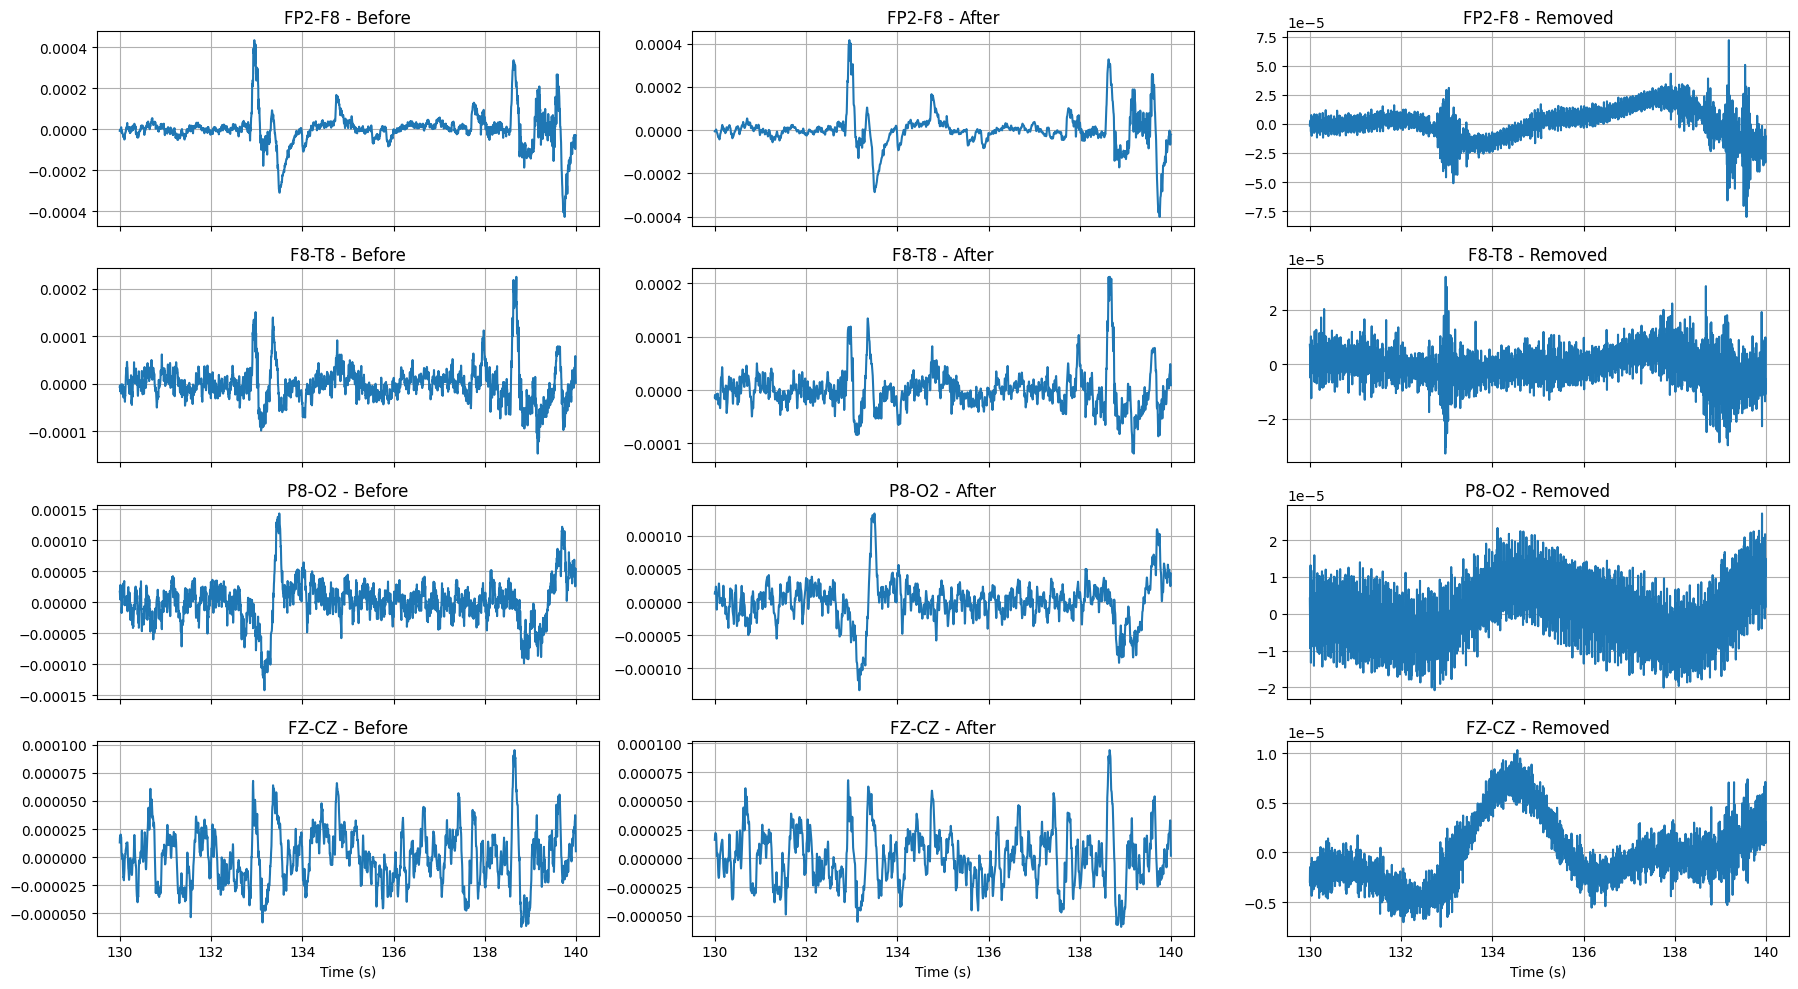

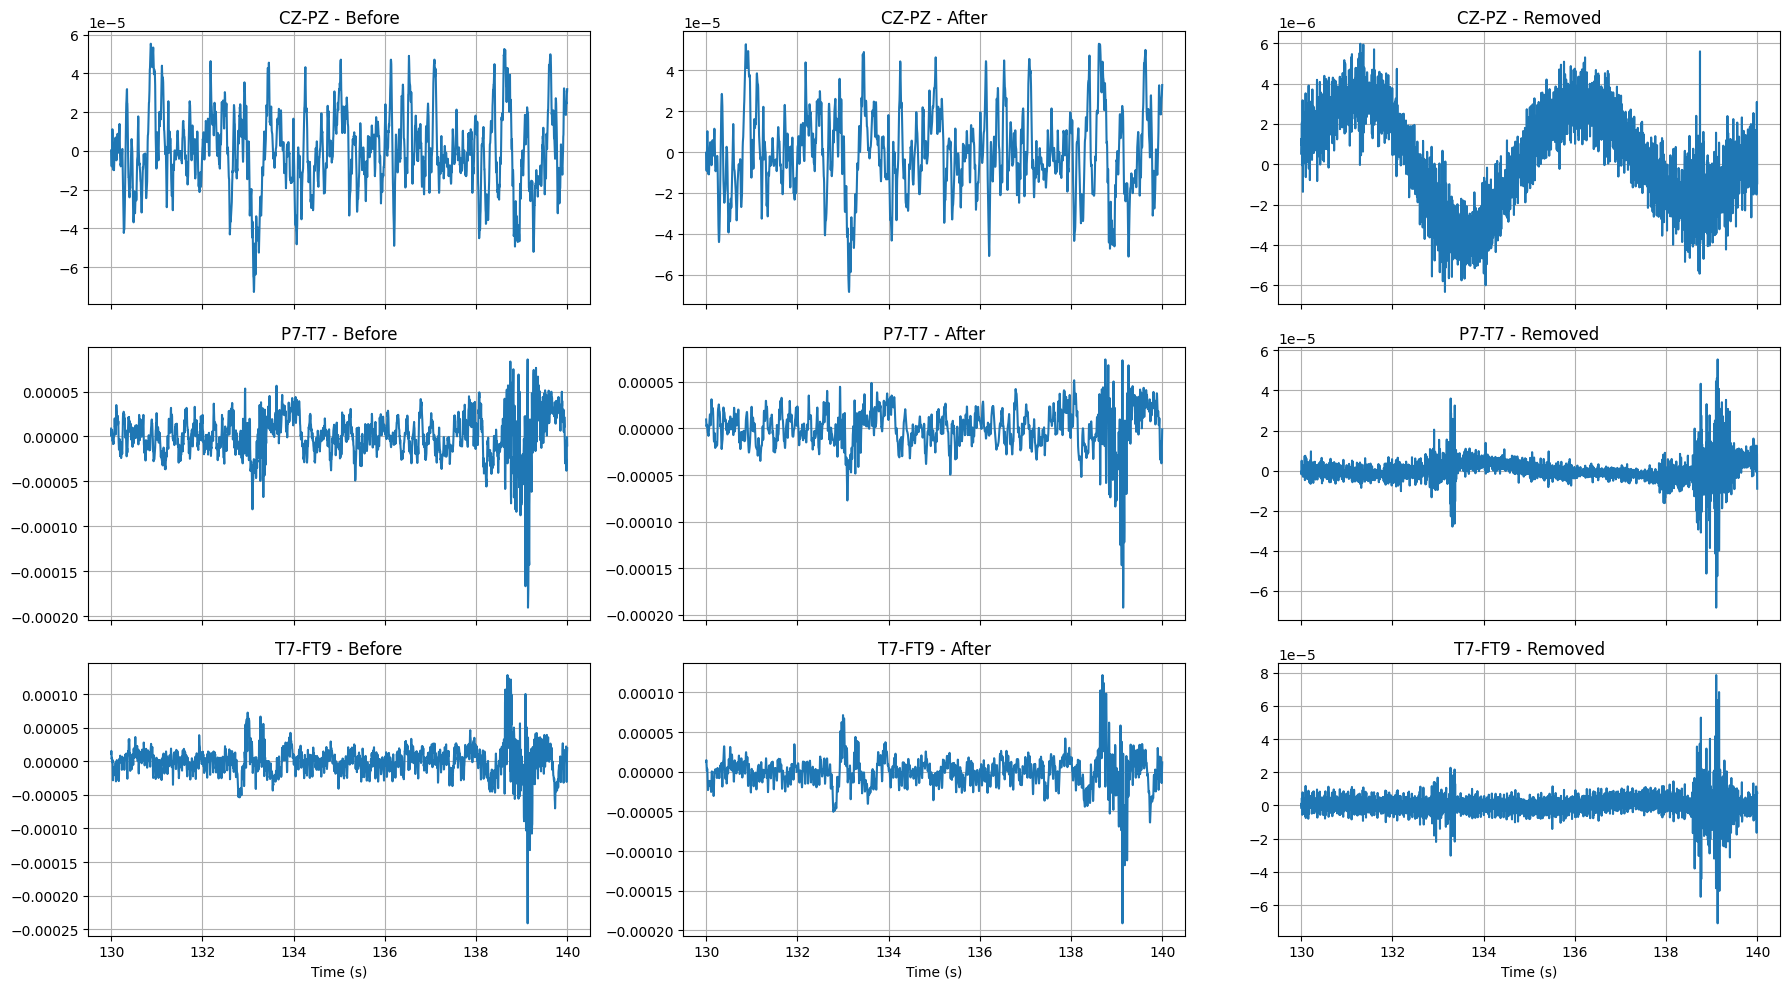

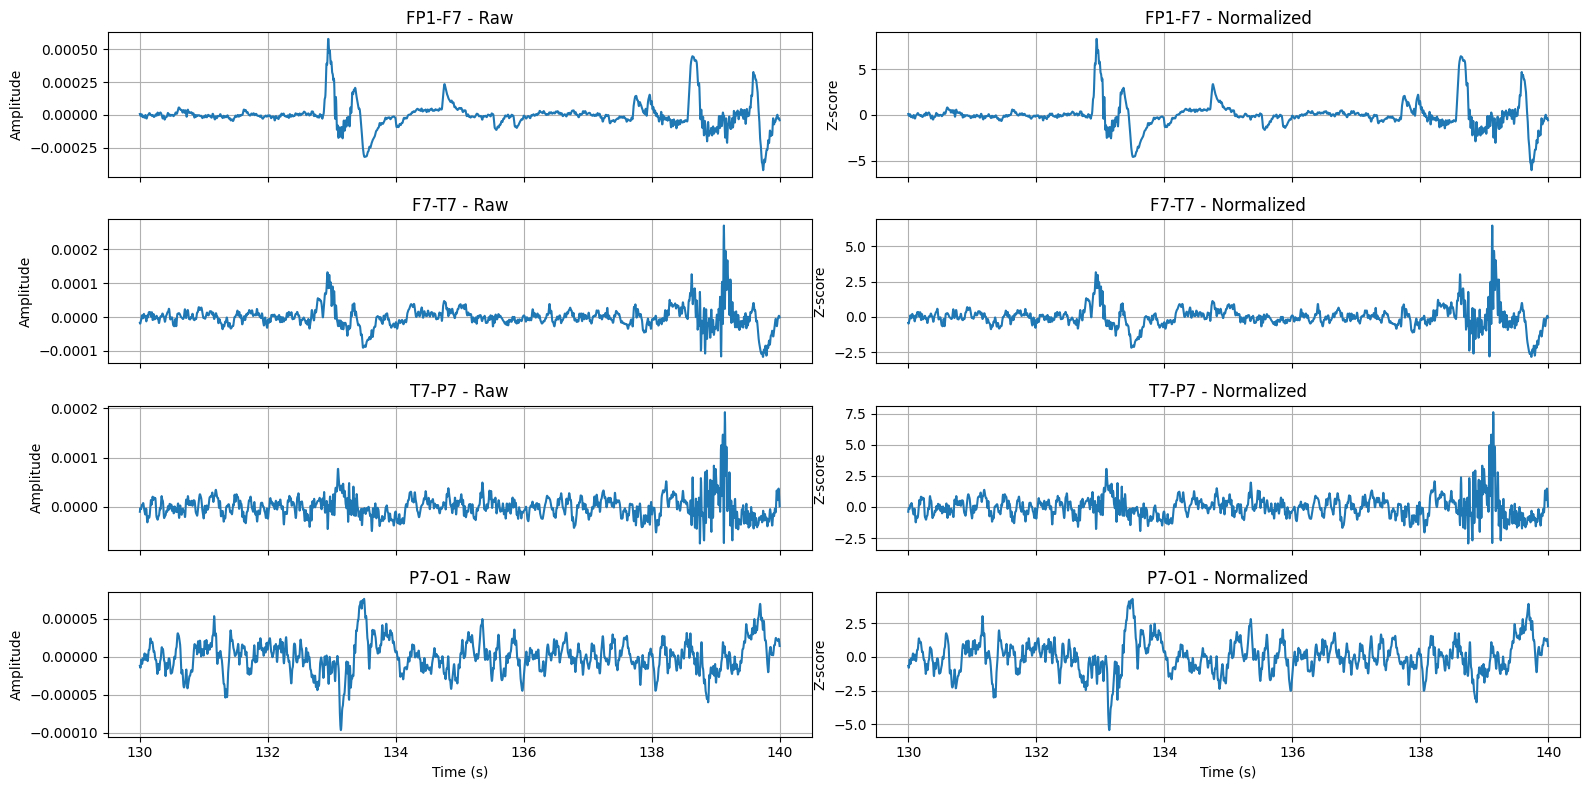

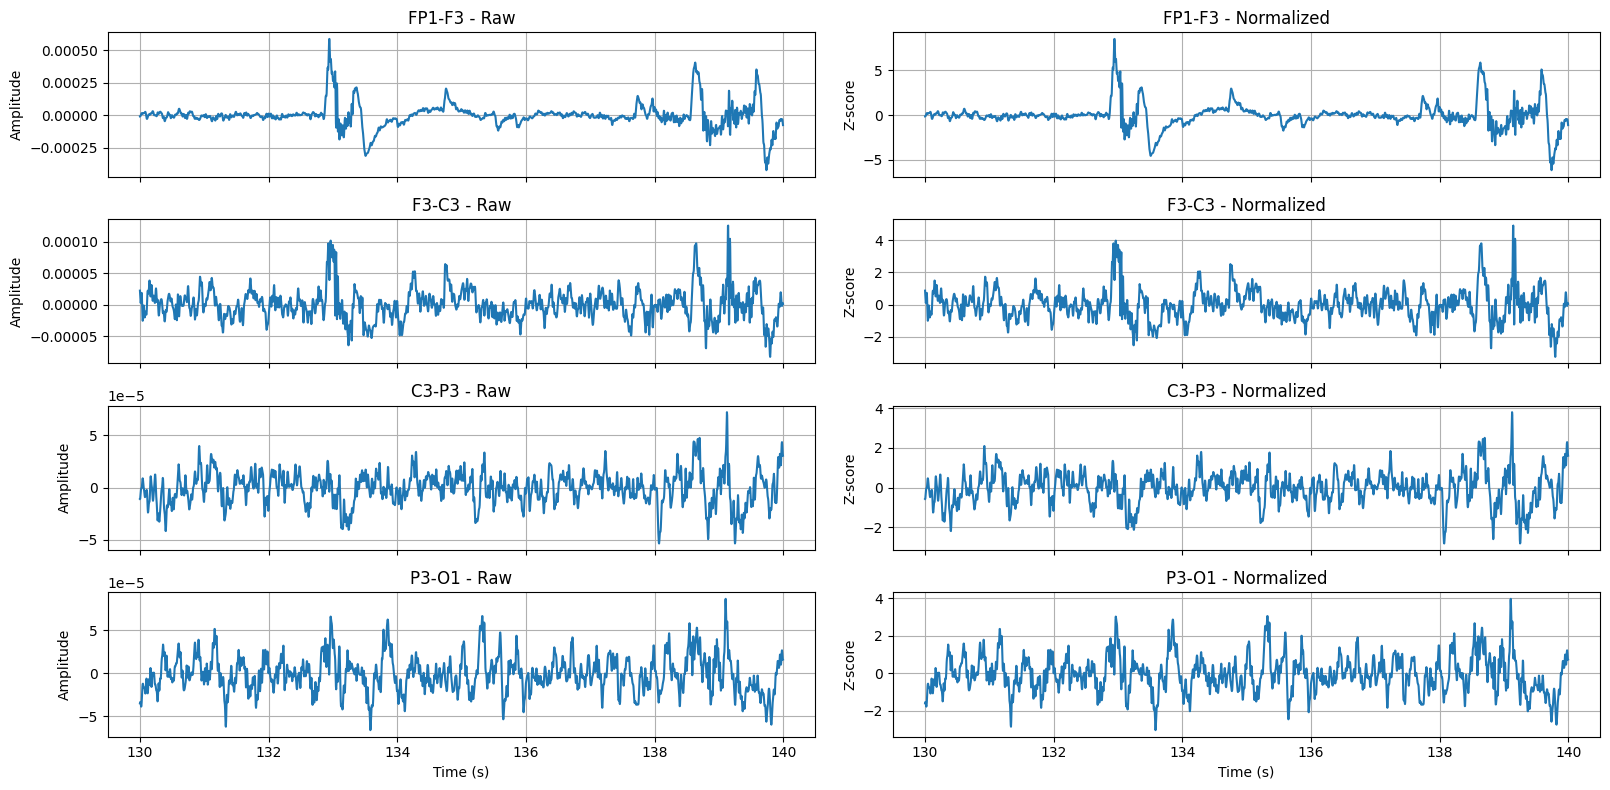

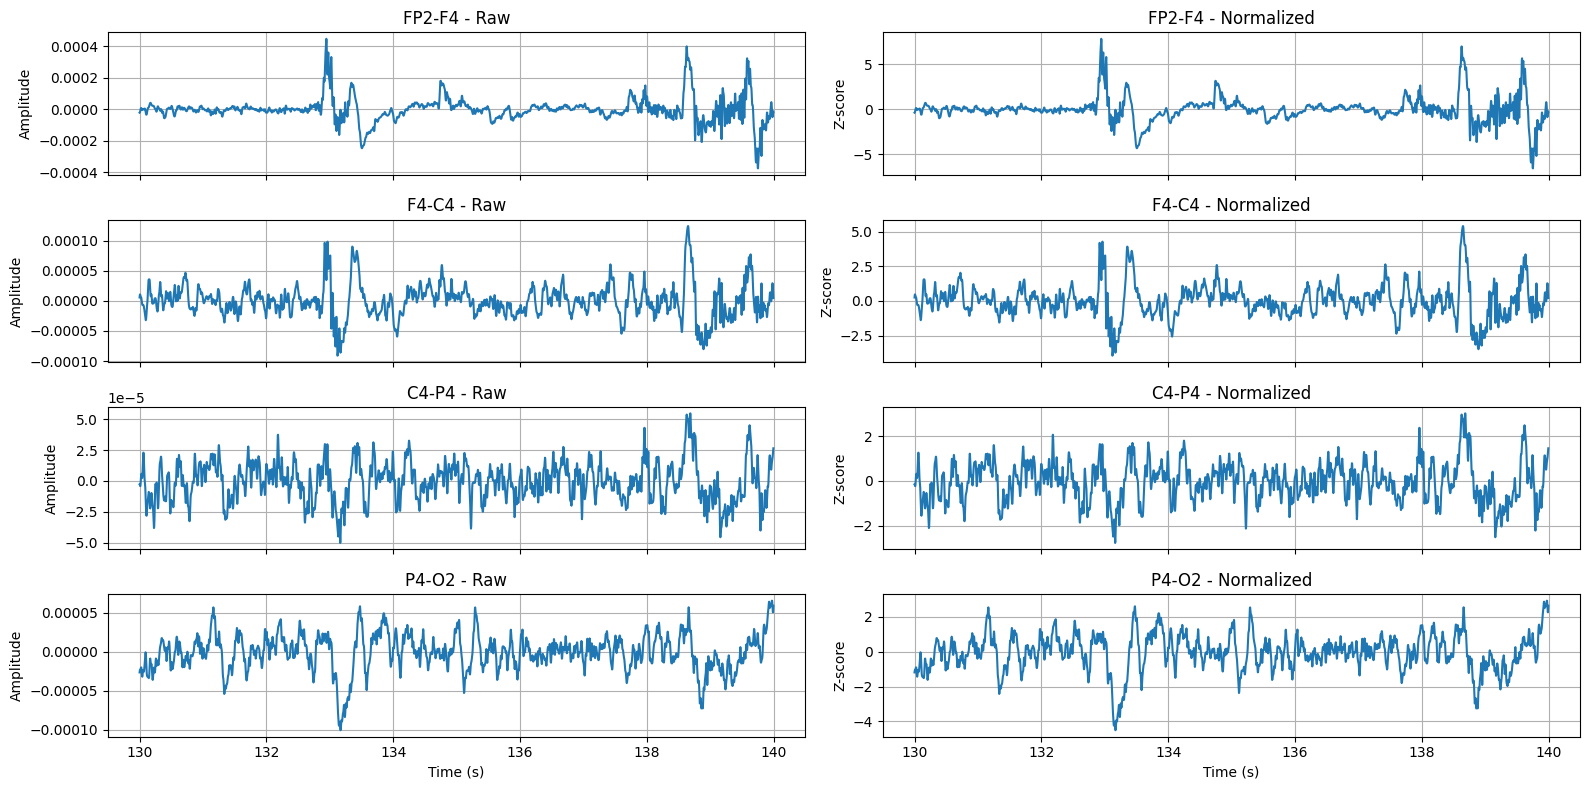

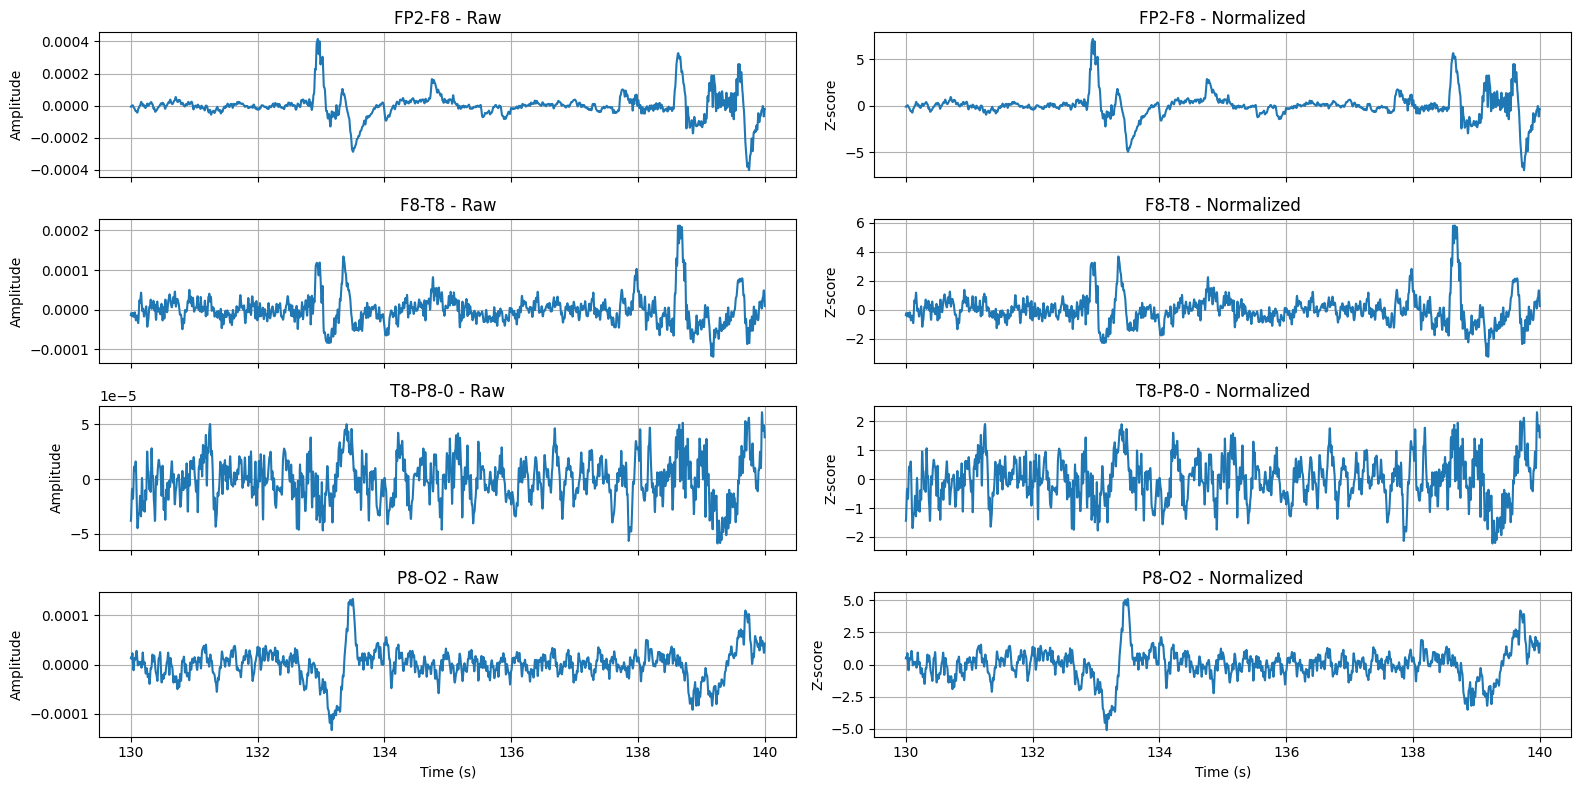

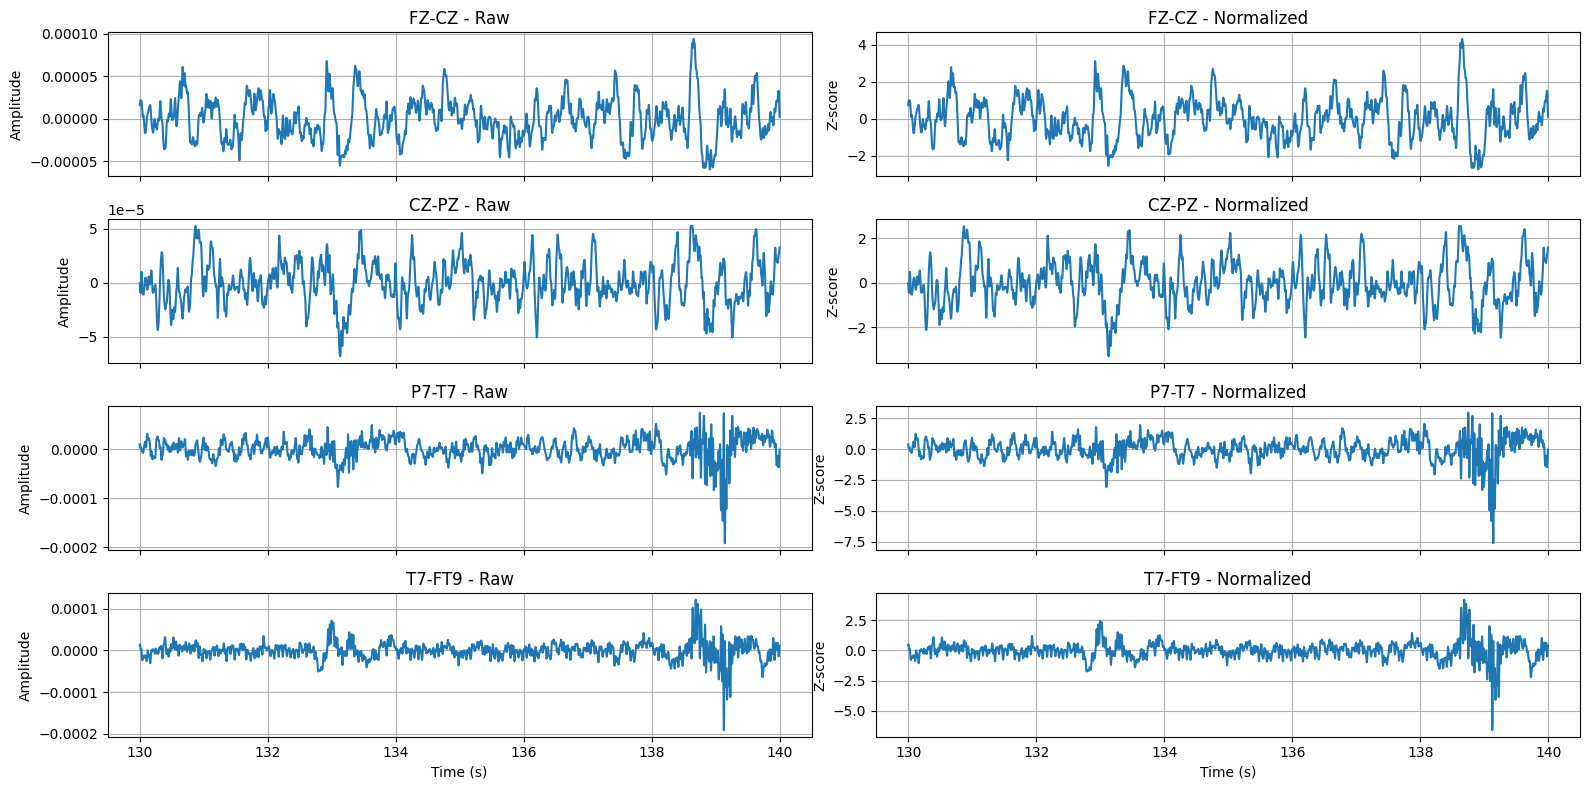

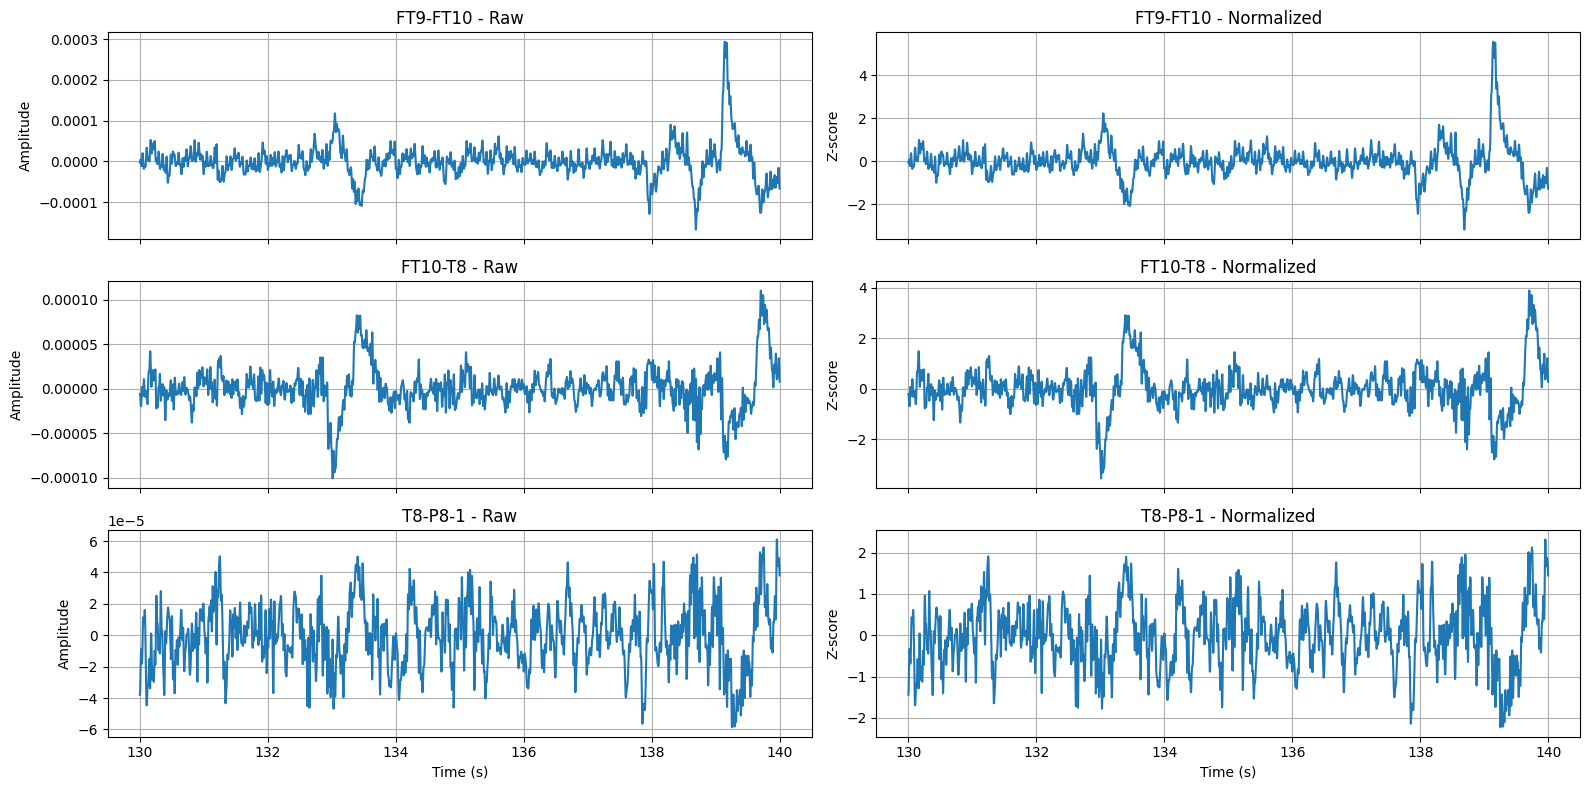

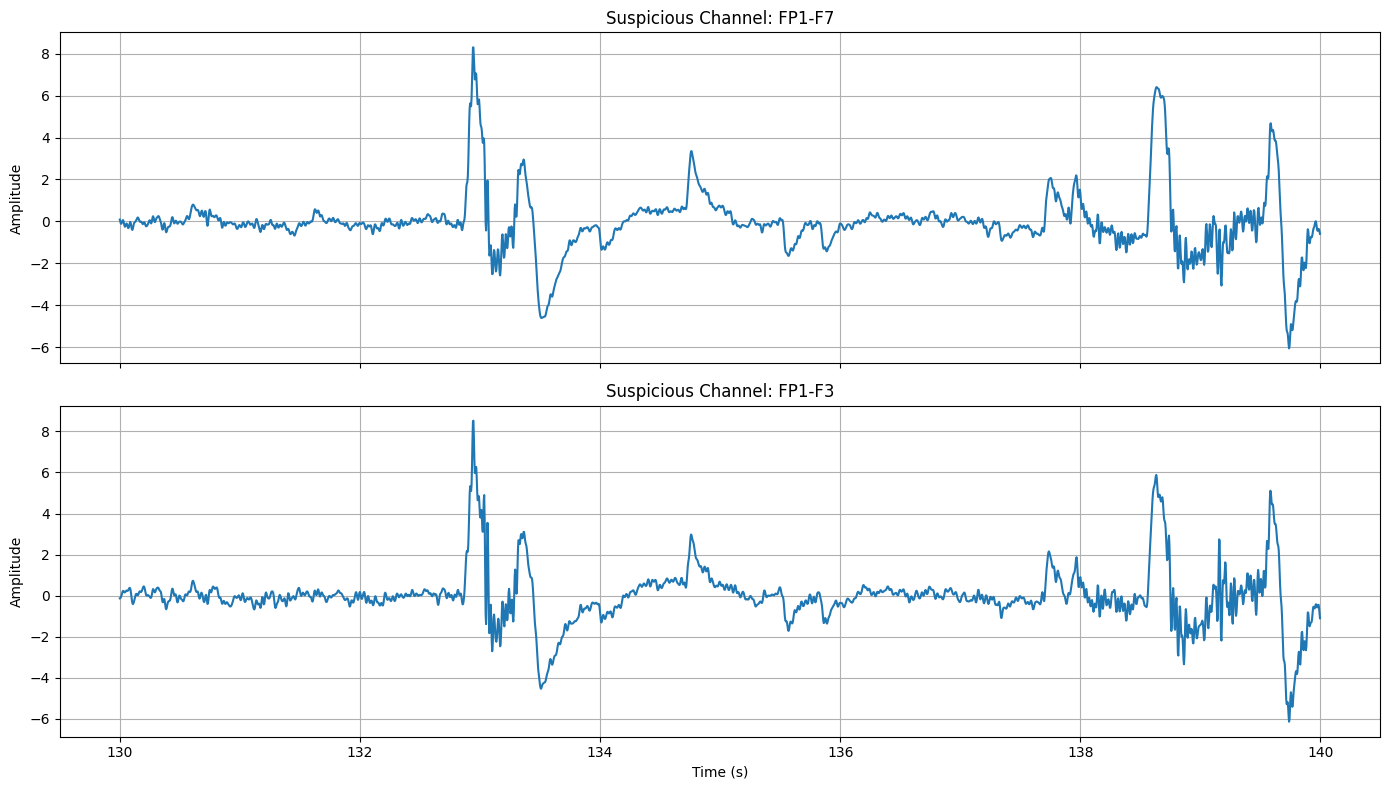

In [3]:
#plots to check the signal quality 

plot_grouped_channel_comparison(
    raw_before=raw_before_filter,
    raw_after=raw_after_filter,
    start_sec=130,
    end_sec=140,
    group_size=4
)
data_before_norm = raw.get_data()
data_after_norm = zscore_normalize(data_before_norm.copy())

plot_raw_vs_normalized_signal(
    raw_data=data_before_norm,
    normalized_data=data_after_norm,
    sfreq=sfreq,
    ch_names=raw.ch_names,
    start_sec=130,
    end_sec=140,
    group_size=4
)

plot_suspicious_channels(
    data=data,
    sfreq=sfreq,
    ch_names=raw.ch_names,
    suspicious_channels=bad_channels,
    start_sec=130,
    end_sec=140
)

# explination for the plots above
 The difference between the original and filtered signal shows that the filtering process successfully removed low-level noise while preserving the important EEG patterns. The removed signal mainly contains high-frequency noise and unwanted interference, indicating that the preprocessing step was effective in improving the signal quality for further analysis.However the amplitude is very small compared to orginal and we can still see the spikes in both because filters removews frequencies do not remove big spijes and artifacts.

PSD before filtering
Effective window size : 8.000 (s)
Plotting power spectral density (dB=True).
PSD after filtering
Effective window size : 8.000 (s)


C:\Users\MSI\Desktop\EEG_FYP\src\utils.py:678: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  raw_before.compute_psd(fmax=fmax).plot()
c:\Users\MSI\Desktop\EEG_FYP\.venv\Lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


Plotting power spectral density (dB=True).


C:\Users\MSI\Desktop\EEG_FYP\src\utils.py:681: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  raw_after.compute_psd(fmax=fmax).plot()
c:\Users\MSI\Desktop\EEG_FYP\.venv\Lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


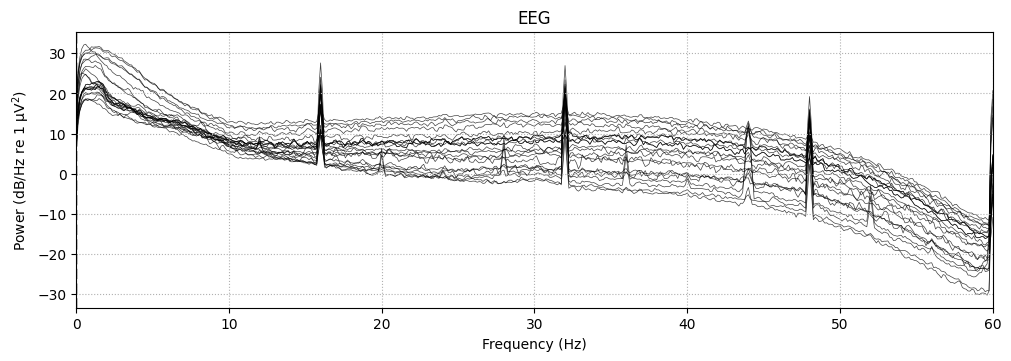

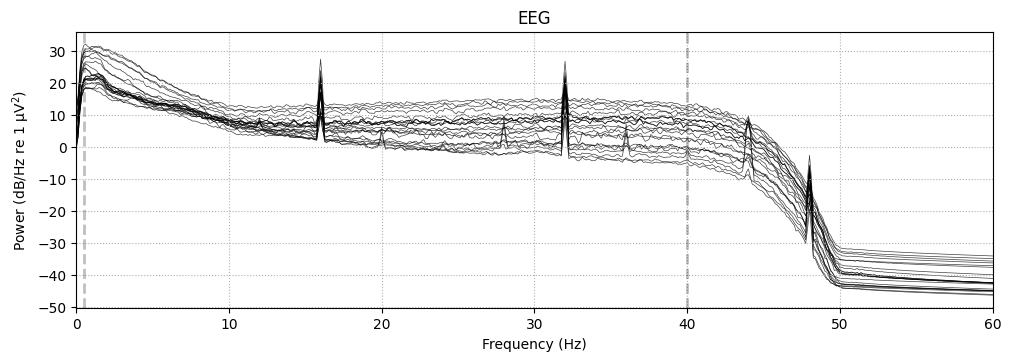

In [4]:
# Frequency cleaning check
plot_psd_before_after(
    raw_before_filter,
    raw_after_filter,
    fmax=60
)

In [5]:
#to check segmentation and model input

check_model_input_ready(X, y)

=== Model Input Check ===
X shape: (1439, 23, 1280)
y shape: (1439,)
OK: Number of windows matches number of labels.
OK: X is 3D.
OK: y is 1D.
Unique labels: [0]
Label counts: {np.int64(0): np.int64(1439)}
X dtype: float64
y dtype: int64
X min: -22.89269566736491
X max: 30.04486693747198
X mean: -3.9930957666819244e-05
X std: 0.9994468687130762
OK: No NaN values in X.
OK: No NaN values in y.


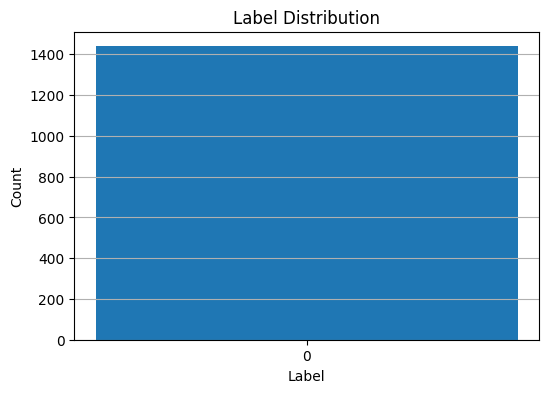

Label counts: {np.int64(0): np.int64(1439)}


In [6]:
#to check label correctness and balance
plot_label_distribution(y)

In [8]:
#Class usefulness: seizure vs non-seizure
plot_seizure_vs_nonseizure_windows(
    X=X,
    y=y,
    ch_names=raw.ch_names,
    channel_name="FP1-F7",
    sfreq=sfreq
)

No seizure windows found in this data.
